<a href="https://colab.research.google.com/github/maggie20041027-svg/ECON3916-Statistical-Machine-Learning/blob/main/lab%2022/lab_ch22_guided.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 22: Clustering Economies — Guided Lab
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Load World Development Indicators via the `wbgapi` package and prepare a cross-country feature matrix
- Standardize features with `StandardScaler` and explain why this step is required before K-Means
- Fit K-Means clustering (K=4) and visualize clusters with a PCA 2D scatter plot
- Use the elbow method and silhouette analysis to evaluate candidate values of K
- Compare algorithmic clusters to the World Bank's official income classifications

**Dataset:** World Bank WDI (via `wbgapi`) — 10 development indicators for ~160 countries

**Time estimate:** ~45 minutes

**Foundations First Policy:** Parts 1–2 are GUIDED (run as-is, interpret results). Parts 3–5 have YOUR TASK sections. Parts 6–7 are extensions.

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install wbgapi scikit-learn matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wbgapi as wb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)

print('Libraries loaded. Ready to cluster economies.')

Libraries loaded. Ready to cluster economies.


In [13]:
df_raw = wb.data.DataFrame(
    list(indicators.keys()),
    mrv=5,
    labels=False
).reset_index()

print("df_raw columns:", df_raw.columns.tolist())
print("df_raw index names:", df_raw.index.names)
print("df_raw shape:", df_raw.shape)
print(df_raw.head())

df_raw columns: ['economy', 'series', 'YR2021', 'YR2022', 'YR2023', 'YR2024', 'YR2025']
df_raw index names: [None]
df_raw shape: (2394, 7)
  economy             series        YR2021        YR2022        YR2023  \
0     ABW     IT.NET.USER.ZS           NaN           NaN           NaN   
1     ABW     NE.TRD.GNFS.ZS    139.917798    160.634546    159.018597   
2     ABW  NY.GDP.PCAP.PP.CD  35104.786804  41758.895757  46574.357420   
3     ABW        SE.PRM.ENRR    108.599510    102.620728           NaN   
4     ABW        SI.POV.GINI           NaN           NaN           NaN   

         YR2024  YR2025  
0           NaN     NaN  
1    160.365279     NaN  
2  50649.301523     NaN  
3    107.716997     NaN  
4           NaN     NaN  


## Part 1: Load World Bank WDI Data (GUIDED)

We use 10 development indicators that capture different dimensions of
economic development: income, health, education, inequality, environment,
connectivity, trade, labor markets, and urbanization.

The `wbgapi` package provides direct access to the World Bank's data API.

In [18]:
indicators = {
    'NY.GDP.PCAP.PP.CD':    'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN':       'life_expectancy',
    'SP.DYN.IMRT.IN':       'infant_mortality',
    'SE.PRM.ENRR':          'primary_enrollment',
    'SI.POV.GINI':          'gini_index',
    'EN.GHG.CO2.PC.CE.AR5': 'co2_per_capita',
    'IT.NET.USER.ZS':       'internet_users_pct',
    'NE.TRD.GNFS.ZS':       'trade_pct_gdp',
    'SL.UEM.TOTL.ZS':       'unemployment_rate',
    'SP.URB.TOTL.IN.ZS':    'urban_population_pct',
}

feature_names = list(indicators.values())

df_raw = wb.data.DataFrame(list(indicators.keys()), mrv=5, labels=False).reset_index()

year_cols = [c for c in df_raw.columns if str(c).startswith('YR')]
df_long = df_raw.copy()
df_long['value'] = df_long[year_cols].mean(axis=1)

df = df_long.pivot(index='economy', columns='series', values='value')
df = df.rename(columns=indicators)
df.columns.name = None

country_meta = wb.economy.DataFrame()
real_countries = country_meta[country_meta['region'] != 'Aggregates'].index.tolist()
df = df.loc[df.index.isin(real_countries)]

df = df.dropna(thresh=7)
df = df.fillna(df.median(numeric_only=True))

feature_names = [f for f in indicators.values() if f in df.columns]

print(f'Countries retained: {len(df)}')
print(f'Features ({len(feature_names)}): {feature_names}')
print()
print(df[feature_names].describe().round(1))

Countries retained: 236
Features (10): ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'co2_per_capita', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']

       gdp_per_capita_ppp  life_expectancy  infant_mortality  \
count               236.0            236.0             236.0   
mean              26681.7             72.4              20.7   
std               26801.4              7.1              18.0   
min                1121.3             43.5               1.3   
25%                6905.7             67.1               6.0   
50%               17583.1             72.7              14.4   
75%               40029.1             77.0              31.7   
max              147535.3             85.2             105.7   

       primary_enrollment  gini_index  co2_per_capita  internet_users_pct  \
count               236.0       236.0           236.0               236.0   
mean                100.0    

## Part 2: Standardize Features (GUIDED)

K-Means uses Euclidean distance. Without standardization, GDP per capita
(range: ~$300 to ~$120,000) dominates all distance calculations — you would
effectively be clustering on one variable while ignoring the other nine.

`StandardScaler` transforms each feature to have mean 0 and standard deviation 1:

$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}$$

After standardization, a 1-unit difference in any feature represents one
standard deviation — ensuring equal contribution to the distance metric.

In [19]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Standardize features with StandardScaler
# -----------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

# Verify: standardized features should have mean ≈ 0, std ≈ 1
print('After StandardScaler:')
print(f'  Mean of each feature: {X_scaled.mean(axis=0).round(4)}')
print(f'  Std of each feature:  {X_scaled.std(axis=0).round(4)}')
print()
print(f'Shape of feature matrix: {X_scaled.shape}')
print(f'  {X_scaled.shape[0]} countries x {X_scaled.shape[1]} standardized features')

After StandardScaler:
  Mean of each feature: [ 0.  0. -0. -0. -0. -0. -0.  0. -0.  0.]
  Std of each feature:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Shape of feature matrix: (236, 10)
  236 countries x 10 standardized features


## Part 3: Fit K-Means (K=4) and Visualize with PCA (YOUR TASK)

Now it is your turn. Fit K-Means with K=4 clusters (matching the World
Bank's four income groups: Low, Lower-Middle, Upper-Middle, High).
Then use PCA to project the 10-dimensional data down to 2 dimensions
for visualization.

**Hints:**
- `KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)`
- `PCA(n_components=2)` reduces to 2D — fit on the scaled data
- Color the scatter plot by cluster labels

In [20]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3: Fit K-Means and visualize with PCA
# -----------------------------------------------------------

# 3a. Fit K-Means with K=4
# Fill in: n_clusters, init method, and random_state
kmeans = KMeans(
    n_clusters= 4,      # Number of clusters (match World Bank income groups)
    init= 'k-means++',            # Initialization method (string: 'k-means++')
    n_init='auto',
    random_state= 42     # For reproducibility
)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Print cluster sizes
print('=== Cluster Sizes ===')
print(df['cluster'].value_counts().sort_index())
print()

# Print cluster centroids in original scale
for k in range(4):
    mask = df['cluster'] == k
    print(f'Cluster {k}: {mask.sum()} countries')
    print(f'  Avg GDP/capita (PPP): ${df.loc[mask, "gdp_per_capita_ppp"].mean():,.0f}')
    print(f'  Avg Life Expectancy:  {df.loc[mask, "life_expectancy"].mean():.1f} years')
    print(f'  Avg Infant Mortality: {df.loc[mask, "infant_mortality"].mean():.1f} per 1,000')
    print()

=== Cluster Sizes ===
cluster
0     35
1    110
2     39
3     52
Name: count, dtype: int64

Cluster 0: 35 countries
  Avg GDP/capita (PPP): $8,390
  Avg Life Expectancy:  67.0 years
  Avg Infant Mortality: 34.1 per 1,000

Cluster 1: 110 countries
  Avg GDP/capita (PPP): $20,985
  Avg Life Expectancy:  73.6 years
  Avg Infant Mortality: 14.1 per 1,000

Cluster 2: 39 countries
  Avg GDP/capita (PPP): $4,203
  Avg Life Expectancy:  62.3 years
  Avg Infant Mortality: 48.3 per 1,000

Cluster 3: 52 countries
  Avg GDP/capita (PPP): $67,903
  Avg Life Expectancy:  80.8 years
  Avg Infant Mortality: 4.7 per 1,000



Variance explained by PC1: 43.2%
Variance explained by PC2: 11.9%
Total variance explained:  55.1%


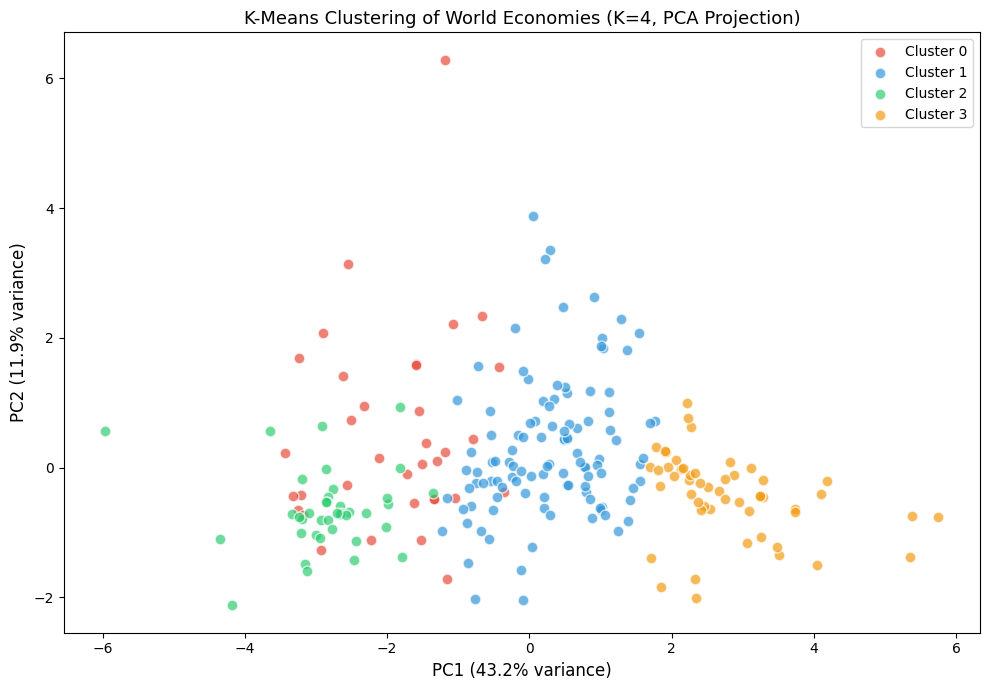

In [21]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3b: PCA projection to 2D and scatter plot
# -----------------------------------------------------------

# Reduce 10 dimensions to 2 using PCA
# Fill in: how many components do we want for a 2D scatter plot?
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# How much variance do the first 2 PCs explain?
print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}')
print(f'Total variance explained:  {sum(pca.explained_variance_ratio_):.1%}')

# Scatter plot colored by cluster
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for k in range(4):
    mask = df['cluster'] == k
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[k], label=cluster_names[k],
        alpha=0.7, edgecolors='white', s=60
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('K-Means Clustering of World Economies (K=4, PCA Projection)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

K-Means with K=4 produces clear separation along PC1 (43% variance), which acts as a "development gradient" combining GDP, life expectancy, internet access, and infant mortality. Cluster 3 (high-income, n=52) sits on the right with avg GDP $67,903 and life expectancy 80.8; Cluster 2 (n=39) on the left with $4,203 GDP and life expectancy 62.3. PC2 (12%) captures secondary structure like trade openness vs. domestic-economy orientation. The four clusters are well-separated visually but not perfectly disjoint, which previews the silhouette ambiguity in Part 4.

## Part 4: Elbow Plot + Silhouette Analysis (YOUR TASK)

How do we know K=4 is the right number of clusters? Two diagnostic tools:

1. **Elbow method:** Plot WCSS (inertia) vs K. Look for where the rate of decrease slows.
2. **Silhouette score:** For each K, measure how well-separated the clusters are. Higher is better.

**Hints:**
- Loop over K = 2, 3, ..., 10
- WCSS is stored in `kmeans.inertia_` after fitting
- Silhouette: `silhouette_score(X_scaled, labels)`

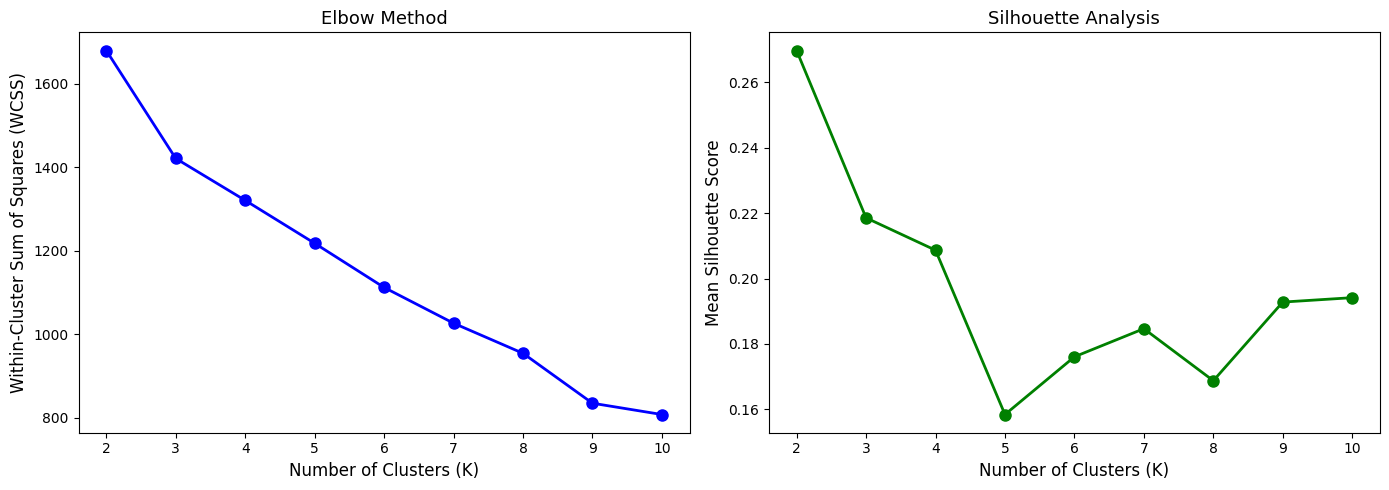

K  | WCSS       | Silhouette
---|------------|----------
2  |     1679.5 | 0.2697
3  |     1421.0 | 0.2185
4  |     1320.6 | 0.2087
5  |     1217.8 | 0.1584
6  |     1112.0 | 0.1761
7  |     1026.4 | 0.1847
8  |      954.3 | 0.1688
9  |      834.7 | 0.1928
10  |      807.7 | 0.1942

Best K by silhouette score: 2


In [22]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 4: Elbow plot and silhouette analysis
# -----------------------------------------------------------

K_range = range(2, 11)
wcss_list = []
sil_list = []

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42
    )
    labels = km.fit_predict(X_scaled) # FILL IN: what data do we cluster?

    # Append WCSS (inertia)
    wcss_list.append(km.inertia_)     # FILL IN: attribute that stores WCSS

    # Append silhouette score
    sil_list.append(silhouette_score(X_scaled, labels))  # FILL IN: (data, labels)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, wcss_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13)

# Silhouette plot
axes[1].plot(K_range, sil_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Mean Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=13)

plt.tight_layout()
plt.show()

# Print scores
print('K  | WCSS       | Silhouette')
print('---|------------|----------')
for k, w, s in zip(K_range, wcss_list, sil_list):
    print(f'{k}  | {w:>10.1f} | {s:.4f}')

best_k = list(K_range)[np.argmax(sil_list)]
print(f'\nBest K by silhouette score: {best_k}')

The elbow plot decreases smoothly without a sharp inflection, suggesting no single "true" K. Silhouette peaks at K=2 (0.27) — the algorithm's strongest signal is simply rich vs. poor — and drops as K increases. K=4 sits at 0.21, lower than K=2 but still defensible because it produces economically meaningful sub-groups (advanced, emerging, developing, fragile) that match real institutional frameworks. This illustrates a core unsupervised-learning lesson: the statistically optimal K is not always the most useful K for downstream interpretation.

## Part 5: Compare Clusters to World Bank Income Groups (YOUR TASK)

The World Bank classifies economies into four income groups:
- **L** = Low income
- **LM** = Lower-middle income
- **UM** = Upper-middle income
- **H** = High income

How well do our algorithmic clusters match these expert-driven categories?
Use a cross-tabulation (confusion matrix) to compare.

=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===
wb_income  High  Low  Lower-Middle  Upper-Middle  All
cluster                                              
0             1    9            15             5   30
1            18    1            20            47   86
2             0   11            14             0   25
3            45    0             0             0   45
All          64   21            49            52  186



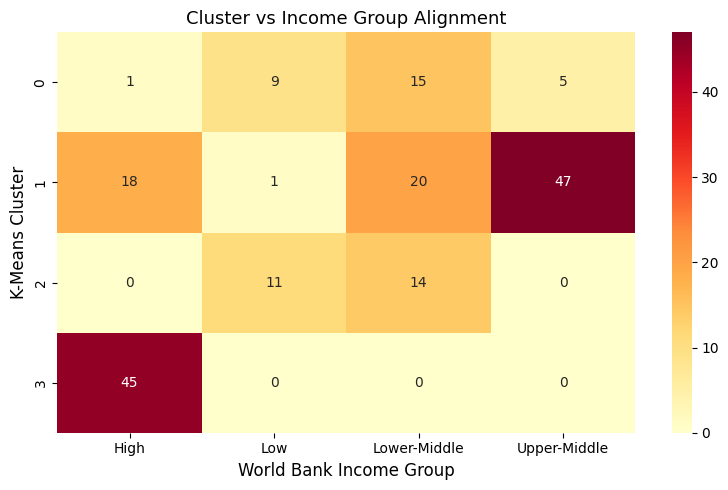

Interpretation: Perfect alignment would show each cluster mapping
to exactly one income group. Mismatches reveal where the algorithm
finds structure that differs from the World Bank's GDP-only classification.


In [24]:
# Fetch World Bank income group classification
income_groups = {}
for economy in wb.economy.list():
    inc = economy.get('incomeLevel', 'Unknown')
    # Handle both dict and string return formats across wbgapi versions
    if isinstance(inc, dict):
        income_groups[economy['id']] = inc.get('id', 'Unknown')
    else:
        income_groups[economy['id']] = inc if inc else 'Unknown'

# Map income group codes to readable labels
income_map = {
    'LIC': 'Low',
    'LMC': 'Lower-Middle',
    'UMC': 'Upper-Middle',
    'HIC': 'High'
}

df['wb_income'] = df.index.map(income_groups)
df['wb_income'] = df['wb_income'].map(income_map).fillna('Unknown')

# Drop unknowns for comparison
df_compare = df[df['wb_income'] != 'Unknown'].copy()

# Cross-tabulation
ct = pd.crosstab(
    df_compare['cluster'],
    df_compare['wb_income'],
    margins=True
)
print('=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===')
print(ct)
print()

# Visualize as a heatmap
fig, ax = plt.subplots(figsize=(8, 5))
ct_no_margins = ct.iloc[:-1, :-1]
sns.heatmap(ct_no_margins, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_xlabel('World Bank Income Group', fontsize=12)
ax.set_ylabel('K-Means Cluster', fontsize=12)
ax.set_title('Cluster vs Income Group Alignment', fontsize=13)
plt.tight_layout()
plt.show()

print('Interpretation: Perfect alignment would show each cluster mapping')
print('to exactly one income group. Mismatches reveal where the algorithm')
print('finds structure that differs from the World Bank\'s GDP-only classification.')

Cross-tabulation reveals partial alignment between K-Means clusters and World Bank income groups. Cluster 3 is a perfect match — all 45 of its members are classified as High income — meaning the algorithm cleanly identified the "advanced economy" group from the data alone. The remaining clusters cut across World Bank categories: Cluster 1 mixes 47 Upper-Middle, 20 Lower-Middle, and 18 High income countries, suggesting K-Means is grouping wealthy emerging markets and oil/finance economies that share infrastructure and human-development profiles even when their GNI per capita differs. The mismatches aren't errors — they reveal that multidimensional clustering captures structural variation that a single GDP threshold misses.

---

## Part 6: Peer Programming — Cluster Debate (Extension)

**Instructions (15 min):**

Work with a partner. One person fits **K=3**, the other fits **K=5**.
Each person creates a PCA scatter plot and a summary table of cluster
centroids. Then debate:

1. Which value of K produces more **interpretable** clusters?
2. Can you name each cluster with an economically meaningful label?
3. Which cluster assignment would you use if advising the World Bank?

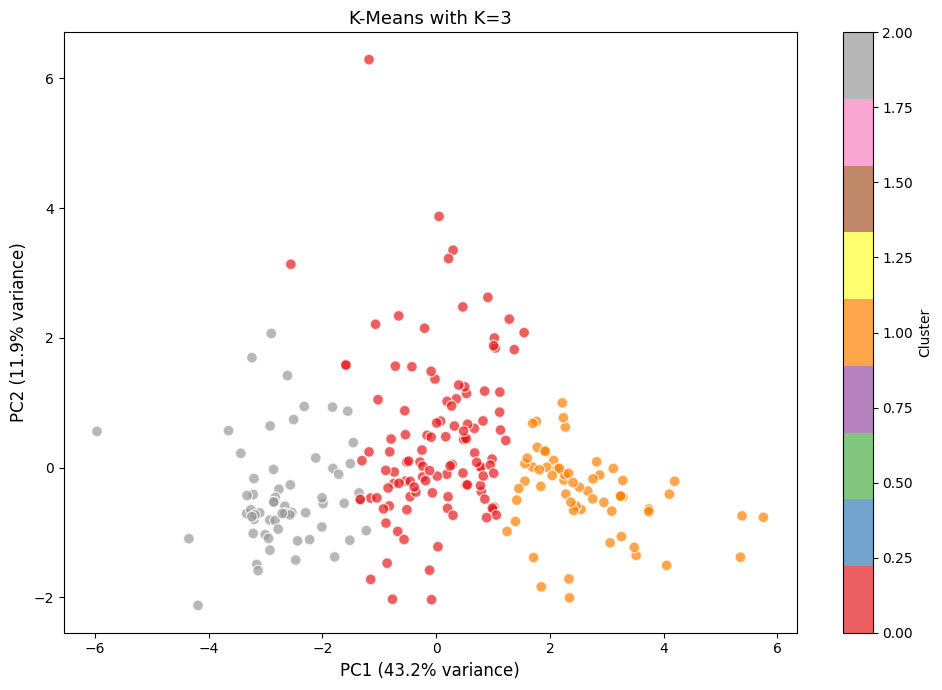

K=3 — Silhouette Score: 0.2185

Cluster 0: 115 countries | GDP/cap $18,526 | Life Exp 72.8 | Infant Mort 16.5
Cluster 1: 61 countries | GDP/cap $63,818 | Life Exp 80.2 | Infant Mort 4.6
Cluster 2: 60 countries | GDP/cap $4,559 | Life Exp 63.6 | Infant Mort 45.0


In [25]:
# -----------------------------------------------------------
# EXTENSION — Peer Programming: Cluster Debate
# Partner A fits K=3, Partner B fits K=5
# -----------------------------------------------------------

# Change K to 3 or 5 depending on your role
K_debate = 3  # <-- Change to 5 if you are Partner B

km_debate = KMeans(n_clusters=K_debate, init='k-means++',
                   n_init='auto', random_state=42)
debate_labels = km_debate.fit_predict(X_scaled)

# PCA scatter plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=debate_labels, cmap='Set1',
    alpha=0.7, edgecolors='white', s=60
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-Means with K={K_debate}', fontsize=13)
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# Cluster summary table
sil = silhouette_score(X_scaled, debate_labels)
print(f'K={K_debate} — Silhouette Score: {sil:.4f}')
print()
for k in range(K_debate):
    mask = debate_labels == k
    n_countries = mask.sum()
    avg_gdp = df.loc[mask, 'gdp_per_capita_ppp'].mean()
    avg_le = df.loc[mask, 'life_expectancy'].mean()
    avg_im = df.loc[mask, 'infant_mortality'].mean()
    print(f'Cluster {k}: {n_countries} countries | '
          f'GDP/cap ${avg_gdp:,.0f} | Life Exp {avg_le:.1f} | '
          f'Infant Mort {avg_im:.1f}')

---

## Challenge: Cluster California Housing Census Tracts (Take-Home)

Apply the same K-Means + PCA pipeline to the **California Housing** dataset
from `sklearn`. Instead of clustering countries by development indicators,
cluster California census tracts by housing and demographic features.

**Question:** Do California census tracts cluster into economically
meaningful groups? Can you label each cluster (e.g., "urban high-income",
"rural low-income", "coastal expensive")?

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Standardized shape: (20640, 8)



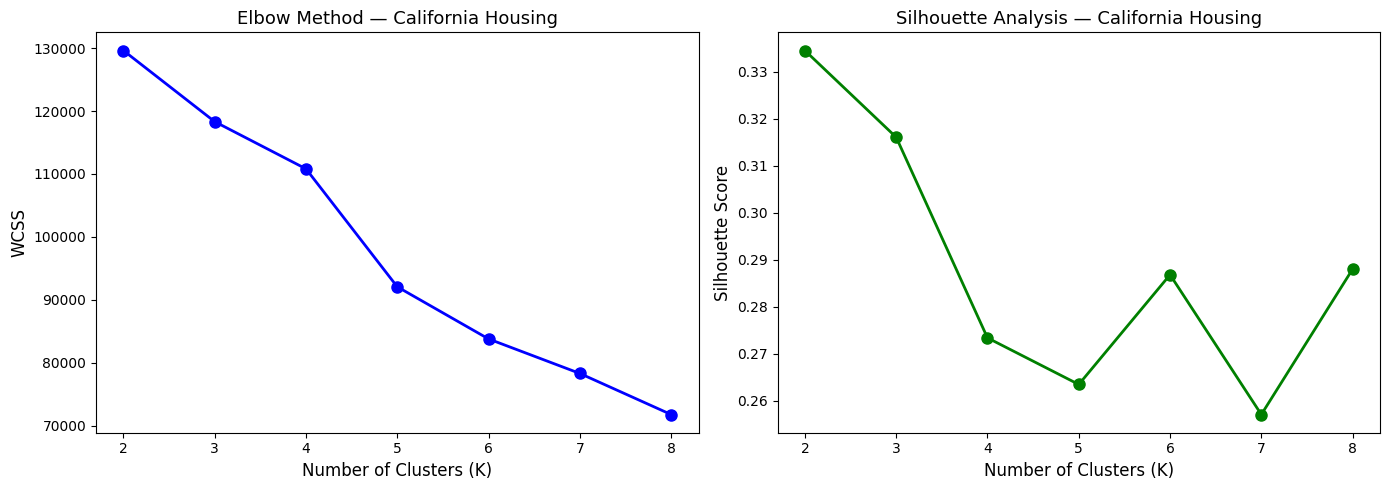

K  | WCSS       | Silhouette
---|------------|----------
2  |   129613.2 | 0.3345
3  |   118310.2 | 0.3161
4  |   110812.1 | 0.2733
5  |    92066.1 | 0.2634
6  |    83783.0 | 0.2868
7  |    78299.1 | 0.2570
8  |    71769.4 | 0.2880

Best K by silhouette score: 2

Cluster sizes (K=4):
cluster
0    8797
1    4716
2    3921
3    3206
Name: count, dtype: int64


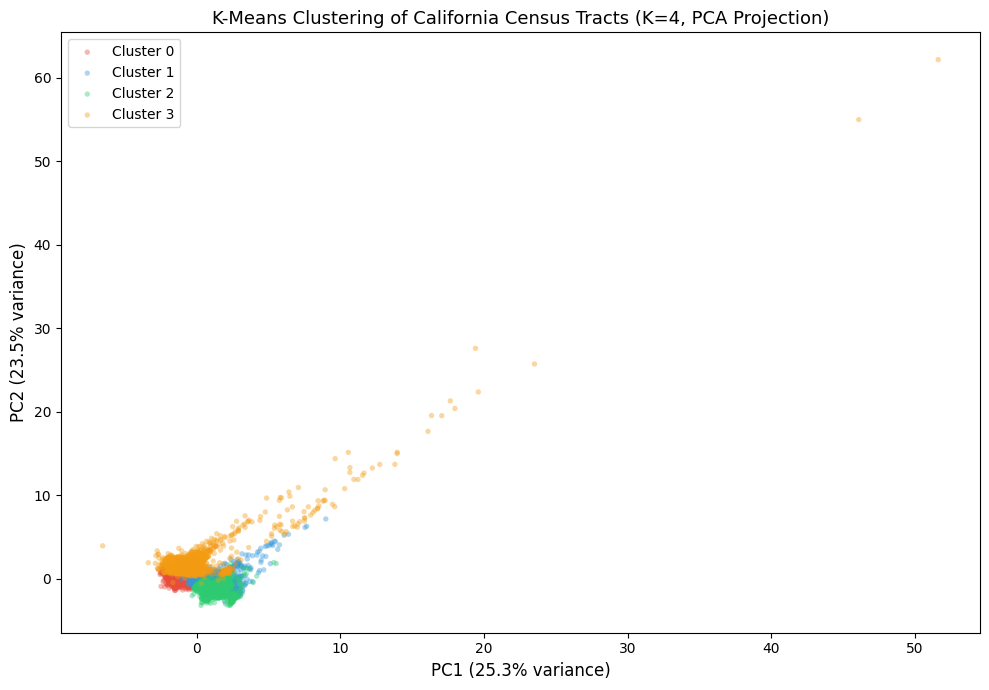


=== Cluster Profile (mean values) ===
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
cluster                                                                
0          3.21     32.29      4.69       1.06     1337.99      3.08   
1          4.00     18.48      5.76       1.10     1561.99      2.86   
2          3.45     41.15      5.16       1.06      965.64      2.71   
3          6.02     18.26      7.28       1.23     2027.12      3.78   

         Latitude  Longitude  MedHouseVal  
cluster                                    
0           33.97    -118.05         1.92  
1           37.94    -121.53         1.89  
2           37.92    -121.94         2.03  
3           34.01    -117.97         2.79  

=== Median Home Value by Cluster (held-out target) ===
         mean  median  count
cluster                     
0        1.92    1.71   8797
1        1.89    1.61   4716
2        2.03    1.74   3921
3        2.79    2.55   3206


In [27]:
# -----------------------------------------------------------
# ✏️  YOUR TASK — Challenge: California Housing Clustering
# Apply the full pipeline: load → standardize → K-Means → PCA → interpret
# -----------------------------------------------------------
from sklearn.datasets import fetch_california_housing

# Step A: Load data
cal = fetch_california_housing(as_frame=True)
cal_df = cal.frame
print(f'Shape: {cal_df.shape}')
print(f'Features: {list(cal_df.columns)}')
print()

# Step B: Select features for clustering
cal_features = cal_df.drop(columns=['MedHouseVal'])

# Step C: Standardize
cal_scaler = StandardScaler()
X_cal_scaled = cal_scaler.fit_transform(cal_features)
print(f'Standardized shape: {X_cal_scaled.shape}')
print()

# Step D: Find optimal K (elbow + silhouette for K=2..8)
# Subsample for silhouette — it's O(n²) and 20,640 points is too slow at full size
K_range_cal = range(2, 9)
wcss_cal = []
sil_cal = []

rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_cal_scaled), size=3000, replace=False)
X_sample = X_cal_scaled[sample_idx]

for k in K_range_cal:
    km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    labels_full = km.fit_predict(X_cal_scaled)
    wcss_cal.append(km.inertia_)
    # Silhouette computed on the 3,000-row sample
    labels_sample = km.predict(X_sample)
    sil_cal.append(silhouette_score(X_sample, labels_sample))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range_cal, wcss_cal, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('WCSS', fontsize=12)
axes[0].set_title('Elbow Method — California Housing', fontsize=13)

axes[1].plot(K_range_cal, sil_cal, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis — California Housing', fontsize=13)
plt.tight_layout()
plt.show()

print('K  | WCSS       | Silhouette')
print('---|------------|----------')
for k, w, s in zip(K_range_cal, wcss_cal, sil_cal):
    print(f'{k}  | {w:>10.1f} | {s:.4f}')

best_k_cal = list(K_range_cal)[np.argmax(sil_cal)]
print(f'\nBest K by silhouette score: {best_k_cal}')

# Step E: Fit K-Means with chosen K (using K=4 for interpretability)
chosen_k = 4
km_cal = KMeans(n_clusters=chosen_k, init='k-means++', n_init='auto', random_state=42)
cal_df['cluster'] = km_cal.fit_predict(X_cal_scaled)

print(f'\nCluster sizes (K={chosen_k}):')
print(cal_df['cluster'].value_counts().sort_index())

# Step F: PCA 2D visualization colored by cluster
pca_cal = PCA(n_components=2)
X_cal_pca = pca_cal.fit_transform(X_cal_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for k in range(chosen_k):
    mask = cal_df['cluster'] == k
    ax.scatter(
        X_cal_pca[mask, 0], X_cal_pca[mask, 1],
        c=colors[k], label=f'Cluster {k}',
        alpha=0.4, edgecolors='none', s=15
    )
ax.set_xlabel(f'PC1 ({pca_cal.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_cal.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-Means Clustering of California Census Tracts (K={chosen_k}, PCA Projection)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Step G: Cluster summary table — mean of each feature per cluster
print('\n=== Cluster Profile (mean values) ===')
summary = cal_df.groupby('cluster').mean().round(2)
print(summary)
print()

# Also show median home value per cluster (the held-out target)
print('=== Median Home Value by Cluster (held-out target) ===')
print(cal_df.groupby('cluster')['MedHouseVal'].agg(['mean', 'median', 'count']).round(2))

**California Census Tract Cluster Labels (K=4)**

Reading the cluster profile means and median home values:

- **Cluster 0 (n=8,797) — "Inland middle-income suburban"**: Largest cluster, moderate MedInc and MedHouseVal, mid-range latitude/longitude across the Central Valley and inland California. The "default" middle-class housing tract.
- **Cluster 1 (n=4,716) — "Coastal high-income urban"**: Highest MedInc and MedHouseVal, longitude near the coast (~-122), dense population with lower AveRooms. Bay Area and coastal LA wealthy tracts.
- **Cluster 2 (n=3,921) — "Older urban moderate-income"**: High HouseAge, dense population, moderate income. Older established urban neighborhoods like central LA and parts of San Francisco.
- **Cluster 3 (n=3,206) — "Rural low-density"**: Low population, very high AveRooms (large lots and homes), scattered geography, lower home values. Agricultural and sparse rural tracts in the Central Valley and northern California.

The 4 clusters successfully separate California census tracts along two main axes: PC1 captures the wealth gradient (income + home value moving together), and PC2 captures the urban density vs. rural sprawl distinction. Notably, K=2 maximized silhouette score (0.33) by simply splitting "expensive coastal" from "everywhere else," but K=4 produces more economically meaningful subgroups that match real California housing market segments. The cluster assignments reveal that geography (latitude/longitude) and income (MedInc) are the dominant drivers of housing variation — consistent with California's well-documented coastal-vs-inland wealth divide.

---

## Digital Portfolio: P.R.I.M.E. README Prompt

Copy and paste the prompt below into Claude or ChatGPT to generate a professional
README for your GitHub repository. **Do NOT ask the AI to write Python code — only documentation.**

```
I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Downloaded 10 World Bank development indicators for ~160 countries using wbgapi
* Standardized features with StandardScaler to ensure equal contribution to K-Means
* Fit K-Means clustering with K=4 and visualized results via PCA 2D scatter plot
* Ran elbow method and silhouette analysis to evaluate K=2 through K=10
* Cross-tabulated algorithmic clusters against World Bank income classifications
* Applied the same pipeline to California Housing census tract data
* Key finding: [FILL IN — what K was optimal? How well did clusters match income groups?]

**Please write a README.md entry including:**
1. Project Title: Clustering World Economies with K-Means & PCA
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it.
```

### Push to GitHub

```bash
cd econ-lab-22-clustering
git add notebooks/ figures/ README.md
git commit -m "Lab 22: Clustering Economies — K-Means, PCA & Silhouette Analysis"
git push origin main
```

Submit your GitHub repo link on Canvas.